In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import sin, cos, tan, pi
import robotics
from robotics import Rx, Ry, Rz, sind, cosd, DH, prettymat
rtd = 180/pi
dtr = pi/180

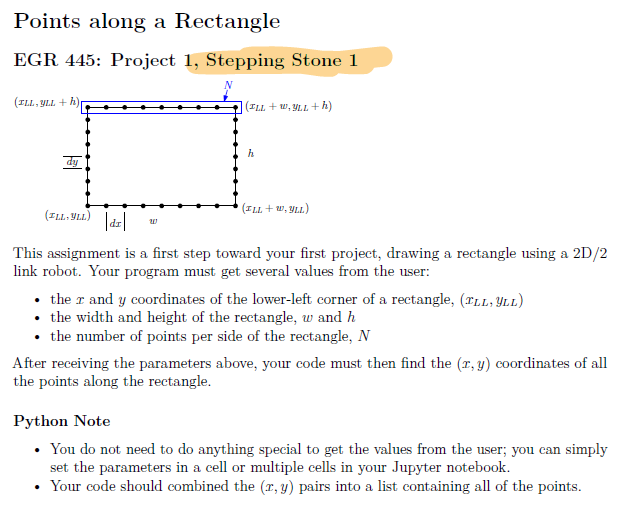

In [2]:
# inputs from user
xll = 1 # x origin
yll = 1 # y origin
w = 2   # width
h = 2   # height
N = 10  # number of steps per side

In [3]:
#define step size
dx = w/N
dy = h/N

#generate bottom coordinants
x_bottom = np.linspace(xll, xll+w-dx, N)  
y_bottom = np.full(N, yll)

#generate right coordinants
x_right = np.full(N, xll + w)  
y_right = np.linspace(yll, yll+h-dy, N)

#generate top coordinants
x_top = np.linspace(xll+w, xll+dx, N)  
y_top = np.full(N,yll+h)

#generate left coordinants
x_left = np.full(N, xll)  
y_left = np.linspace(yll+h, yll, N)

#combine bottom, right, top, left into one array
x_path = np.concatenate((x_bottom, x_right, x_top, x_left), axis=0) 
y_path = np.concatenate((y_bottom, y_right, y_top, y_left), axis=0) 

#combine x and y into one array
tip_path = np.column_stack((x_path, y_path))
tip_path

array([[1.        , 1.        ],
       [1.2       , 1.        ],
       [1.4       , 1.        ],
       [1.6       , 1.        ],
       [1.8       , 1.        ],
       [2.        , 1.        ],
       [2.2       , 1.        ],
       [2.4       , 1.        ],
       [2.6       , 1.        ],
       [2.8       , 1.        ],
       [3.        , 1.        ],
       [3.        , 1.2       ],
       [3.        , 1.4       ],
       [3.        , 1.6       ],
       [3.        , 1.8       ],
       [3.        , 2.        ],
       [3.        , 2.2       ],
       [3.        , 2.4       ],
       [3.        , 2.6       ],
       [3.        , 2.8       ],
       [3.        , 3.        ],
       [2.8       , 3.        ],
       [2.6       , 3.        ],
       [2.4       , 3.        ],
       [2.2       , 3.        ],
       [2.        , 3.        ],
       [1.8       , 3.        ],
       [1.6       , 3.        ],
       [1.4       , 3.        ],
       [1.2       , 3.        ],
       [1.

## add in inverse kinematics to solve for angles at a point

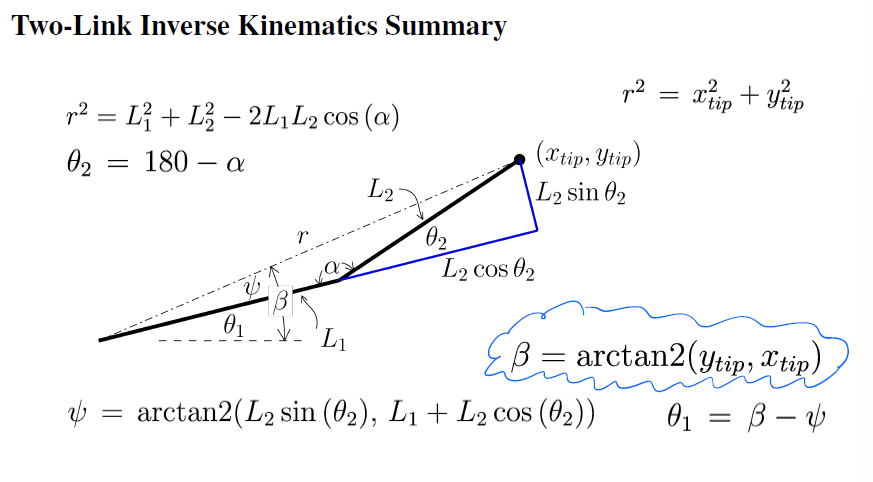

In [4]:
#define link lengths
l1 = 3 # base link
l2 = 4 # tip link

#distance from origin to tip
r_squared = tip_path[:,0]**2 + tip_path[:,1]**2

#law of cos for angle between links
alpha_temp = (r_squared-l1**2-l2**2)/(-2*l1*l2)
alpha = np.arccos(alpha_temp)

#vertical angle theorem for theta 2
theta2 = 180 - alpha*rtd

#triangle in link1 co-ordinant system for psi
psi = np.arctan2(l2*sind(theta2),l1+l2*cosd(theta2))

#angle of r to x-axis
beta = np.arctan2(tip_path[:,1],tip_path[:,0])

#difference in beta and psi is theta 1
theta1 = beta - psi

print("theta 1:\n",theta1)
print("theta 2:\n",theta2)

theta 1:
 [-1.41553541 -1.38418322 -1.35266351 -1.32094499 -1.2889947  -1.25677763
 -1.22425632 -1.19139043 -1.15813613 -1.12444546 -1.09026556 -1.01190314
 -0.9334641  -0.85540499 -0.77808311 -0.70175882 -0.62660306 -0.55270775
 -0.48009722 -0.40873931 -0.338555   -0.33980111 -0.33748229 -0.3313933
 -0.3213044  -0.3069677  -0.28812578 -0.26452332 -0.2359221  -0.20211957
 -0.16297034 -0.24852685 -0.34074104 -0.44137389 -0.55270242 -0.67771324
 -0.82036501 -0.98592626 -1.18135256 -1.41553541]
theta 2:
 [163.40215786 160.05155641 156.68363014 153.29514775 149.88270525
 146.44269024 142.97124085 139.46419789 135.91704824 132.32485733
 128.68218745 127.34886956 125.80299001 124.05579774 122.11813409
 120.         117.71022205 115.25620366 112.64374026 109.87687407
 106.9577633  109.87687407 112.64374026 115.25620366 117.71022205
 120.         122.11813409 124.05579774 125.80299001 127.34886956
 128.68218745 132.72637818 136.70901518 140.63743767 144.51824679
 148.35743699 152.16050289 155.

## send angle to arduino and move robot to next point (PID?)